# Immunotherapy Response in Melanoma: Longitudinal Single-Cell Analysis

**Dataset**: Sade-Feldman et al., Cell 2018 (GSE120575)

This notebook demonstrates how to analyze longitudinal single-cell data from a clinical immunotherapy study, comparing immune dynamics between responders and non-responders to anti-PD-1 therapy.

## Background

Sade-Feldman et al. (Cell 2018) profiled tumor-infiltrating immune cells from melanoma patients **before and during** anti-PD-1 checkpoint inhibitor therapy. This landmark study identified transcriptional programs associated with clinical response.

### Study Design

**This is a prospective longitudinal study:**
- Patients received anti-PD-1 immunotherapy (pembrolizumab or nivolumab)
- Tumor biopsies collected **Pre-treatment** (baseline) and **Post-treatment** (on therapy)
- Response assessed by RECIST criteria: Complete/Partial Response vs Progressive Disease

**Key biological questions:**
- Do responders and non-responders have different baseline immune states?
- How does the immune microenvironment change with therapy?
- Are there response-specific trajectories (Difference-in-Differences)?

### Analysis Strategy

1. **Cross-sectional comparisons**: Responder vs Non-responder at each timepoint
2. **Within-arm longitudinal**: Pre→Post changes within each response group
3. **Difference-in-Differences (DiD)**: Do responders change differently than non-responders?

**Statistical considerations:**
- Participant-level aggregation to avoid pseudoreplication
- FDR correction for multiple testing
- Bootstrap inference for small sample sizes

## 1. Setup


In [1]:
# Imports - consolidated
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import mannwhitneyu, wilcoxon, ttest_ind
from statsmodels.stats.multitest import multipletests

import sctrial as st

# Configuration
MIN_GENES_FOR_SCORE = 5
MIN_PARTICIPANTS_FOR_COMPARISON = 3
FDR_ALPHA = 0.25
SEED = 42
RESPONSE_COL = "response_harmonized"

pd.options.mode.chained_assignment = None
print(f"sctrial version: {st.__version__ if hasattr(st, '__version__') else 'dev'}")


sctrial version: 0.2.1.dev1


## 2. Data Loading and Processing


In [2]:
# Dataset loader (from sctrial)
from sctrial.datasets import load_sade_feldman


### 2.1 Load processed AnnData

We harmonize response labels at the **participant level** (majority label) because a few participants have mixed response annotations across cells/samples. Mixed cases are reported below.


In [3]:
# Load data - using full dataset for reliable longitudinal analysis
adata = load_sade_feldman(max_cells_per_participant_visit=None)  # No subsampling

# Harmonize response labels at participant level
resp_counts = (
    adata.obs
    .groupby(["participant_id", "response"], observed=True)
    .size()
    .reset_index(name="n_cells")
)
resp_n = resp_counts.groupby("participant_id")["response"].nunique()
mixed_ids = resp_n[resp_n > 1].index.tolist()

dominant_response = (
    resp_counts
    .sort_values(["participant_id", "n_cells"], ascending=[True, False])
    .drop_duplicates("participant_id")
    .set_index("participant_id")["response"]
)

adata.obs[RESPONSE_COL] = adata.obs["participant_id"].map(dominant_response)
missing_resp = adata.obs[RESPONSE_COL].isna().sum()

print("")
print("=== Dataset Summary ===")
print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")
print(f"Participants: {adata.obs['participant_id'].nunique()}")
print(f"Original response labels: {adata.obs['response'].unique().tolist()}")
print(f"Harmonized response labels: {adata.obs[RESPONSE_COL].unique().tolist()}")
print(f"Visits: {adata.obs['visit'].unique().tolist()}")

print("")
print("=== Response Label Consistency ===")
print(f"Participants with mixed response labels: {len(mixed_ids)}")
if mixed_ids:
    print("Using participant-level majority response for analyses.")
    display(
        resp_counts[resp_counts["participant_id"].isin(mixed_ids)]
        .sort_values(["participant_id", "n_cells"], ascending=[True, False])
    )
if missing_resp:
    print(f"WARNING: {missing_resp} cells are missing harmonized response labels.")

# Detailed pairing analysis
print("")
print("=== Longitudinal Pairing Analysis ===")
participant_visits = adata.obs.groupby("participant_id")["visit"].apply(set).reset_index()
participant_visits["has_Pre"] = participant_visits["visit"].apply(lambda x: "Pre" in x)
participant_visits["has_Post"] = participant_visits["visit"].apply(lambda x: "Post" in x)
participant_visits["is_paired"] = participant_visits["has_Pre"] & participant_visits["has_Post"]

# Add harmonized response info
participant_visits[RESPONSE_COL] = participant_visits["participant_id"].map(dominant_response)

print("")
print(f"Total participants: {len(participant_visits)}")
print(f"  Pre only: {(participant_visits['has_Pre'] & ~participant_visits['has_Post']).sum()}")
print(f"  Post only: {(~participant_visits['has_Pre'] & participant_visits['has_Post']).sum()}")
print(f"  Both (paired): {participant_visits['is_paired'].sum()}")

paired_by_resp = participant_visits[participant_visits["is_paired"]].groupby(RESPONSE_COL).size()
print("")
print("Paired participants by response (harmonized):")
for resp, count in paired_by_resp.items():
    print(f"  {resp}: {count}")

print("")
print(f"Obs columns: {sorted(adata.obs.columns.tolist())}")


Processed file parameters differ; reprocessing.
Processing raw data (this may take a minute)...


Using full dataset: 13,183 cells (no subsampling)


Saved processed file: /Users/omarm/Documents/Research/projects/sc-trialdiff/data/processed/sade_feldman_processed_v5.h5ad
Loaded Sade-Feldman dataset: 13,183 cells, 55,737 genes

=== Dataset Summary ===
Cells: 13,183
Genes: 55,737
Participants: 25
Original response labels: ['Responder', 'Non-responder']
Harmonized response labels: ['Responder', 'Non-responder']
Visits: ['Pre', 'Post']

=== Response Label Consistency ===
Participants with mixed response labels: 3
Using participant-level majority response for analyses.


,participant_id,response,n_cells
1,P1,Responder,519
0,P1,Non-responder,353
5,P4,Responder,675
4,P4,Non-responder,311
21,P28,Non-responder,741
22,P28,Responder,337



=== Longitudinal Pairing Analysis ===

Total participants: 25
  Pre only: 8
  Post only: 7
  Both (paired): 10

Paired participants by response (harmonized):
  Non-responder: 7
  Responder: 3

Obs columns: ['Sample name', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'cell_type', 'characteristics: therapy', 'description', 'molecule', 'organism', 'participant_id', 'patient_raw', 'processed data file ', 'raw file', 'response', 'response_harmonized', 'source name', 'time_label', 'visit']


### 2.2 Quick exploratory summaries


=== Sample Sizes ===

Cells per Response x Visit:


visit,Post,Pre
response_harmonized,,
Non-responder,5760,3229
Responder,1762,2432



Participants per Response x Visit:


visit,Post,Pre
response_harmonized,,
Non-responder,13,10
Responder,4,8


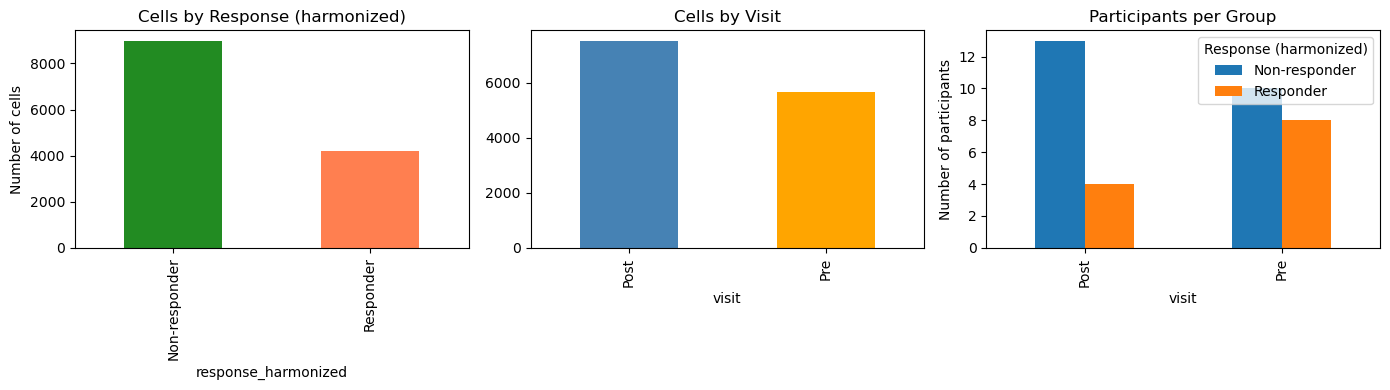

In [4]:
# Sample size summary
print("=== Sample Sizes ===")
print("")

# Cells per group
cell_counts = adata.obs.groupby([RESPONSE_COL, "visit"], observed=True).size().unstack(fill_value=0)
print("Cells per Response x Visit:")
display(cell_counts)

# Participants per group
participant_counts = (
    adata.obs
    .groupby([RESPONSE_COL, "visit"], observed=True)["participant_id"]
    .nunique()
    .unstack(fill_value=0)
)
print("")
print("Participants per Response x Visit:")
display(participant_counts)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Cells by response
adata.obs[RESPONSE_COL].value_counts().plot(
    kind="bar", ax=axes[0], color=["forestgreen", "coral"]
)
axes[0].set_title("Cells by Response (harmonized)")
axes[0].set_ylabel("Number of cells")

# Cells by visit
adata.obs["visit"].value_counts().plot(
    kind="bar", ax=axes[1], color=["steelblue", "orange"]
)
axes[1].set_title("Cells by Visit")

# Participants per group
participant_counts.T.plot(kind="bar", ax=axes[2])
axes[2].set_title("Participants per Group")
axes[2].set_ylabel("Number of participants")
axes[2].legend(title="Response (harmonized)")

plt.tight_layout()
plt.show()


## 3. Trial Design and Timepoint Strategy


In [5]:
# Define study design
visit_col = "visit"
adata.obs[visit_col] = adata.obs[visit_col].astype(str)
visits = [v for v in ["Pre", "Post"] if v in adata.obs[visit_col].unique()]
print(f"Available visits: {visits}")

# Participant-level response mapping (harmonized)
participant_response = adata.obs.groupby("participant_id")[RESPONSE_COL].first()

# Check longitudinal pairing (participant level)
participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_Pre"] = participant_summary[visit_col].apply(lambda x: "Pre" in x)
participant_summary["has_Post"] = participant_summary[visit_col].apply(lambda x: "Post" in x)
participant_summary["is_paired"] = participant_summary["has_Pre"] & participant_summary["has_Post"]
participant_summary[RESPONSE_COL] = participant_summary["participant_id"].map(participant_response)

paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])
n_paired = len(paired_ids)

# Paired participants by response (harmonized)
paired_by_response = (
    participant_summary[participant_summary["is_paired"]]
    .groupby(RESPONSE_COL)
    .size()
    .to_dict()
)

paired_ids_by_response = {
    arm: set(
        participant_summary[
            (participant_summary["is_paired"]) & (participant_summary[RESPONSE_COL] == arm)
        ]["participant_id"]
    )
    for arm in ["Responder", "Non-responder"]
}

print("")
print("Longitudinal pairing:")
print(f"  Total paired participants (Pre + Post): {n_paired}")
print(f"  Paired Responders: {paired_by_response.get('Responder', 0)}")
print(f"  Paired Non-responders: {paired_by_response.get('Non-responder', 0)}")

# Check if DiD analysis is feasible
MIN_PAIRED_PER_ARM = 3
can_do_did = (
    paired_by_response.get("Responder", 0) >= MIN_PAIRED_PER_ARM and
    paired_by_response.get("Non-responder", 0) >= MIN_PAIRED_PER_ARM
)

if can_do_did:
    print("")
    print(f"  DiD analysis is feasible (>={MIN_PAIRED_PER_ARM} paired per arm)")
else:
    print("")
    print(f"  WARNING: DiD analysis may be underpowered (<{MIN_PAIRED_PER_ARM} paired in one arm)")

# Define trial design for sctrial
# Note: "Responder" is the group of interest (like "treated" in a trial context)
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col=RESPONSE_COL,
    arm_treated="Responder",      # Group of primary interest
    arm_control="Non-responder",  # Comparison group
    celltype_col="cell_type",
)

print("")
print("Design configured:")
print(f"  Participant: {design.participant_col}")
print(f"  Visit: {design.visit_col}")
print(f"  Comparison: {design.arm_treated} vs {design.arm_control}")


Available visits: ['Pre', 'Post']

Longitudinal pairing:
  Total paired participants (Pre + Post): 10
  Paired Responders: 3
  Paired Non-responders: 7

  DiD analysis is feasible (>=3 paired per arm)

Design configured:
  Participant: participant_id
  Visit: visit
  Comparison: Responder vs Non-responder


## 4. Immune Signatures

We define gene signatures relevant to immunotherapy response, based on the original Sade-Feldman paper and broader immuno-oncology literature:

- **Cytotoxicity**: Effector function of CD8 T cells and NK cells - associated with anti-tumor immunity
- **Exhaustion**: Dysfunctional T cell state - elevated exhaustion may predict poor response
- **IFN Response**: Interferon-gamma signaling - can indicate immune activation
- **Memory**: Memory T cell markers - may predict durable responses
- **Activation**: T cell activation markers - early response indicator

In [6]:
available_genes = set(adata.var_names)

# Define immunotherapy-relevant gene signatures
# Based on Sade-Feldman et al. and broader immuno-oncology literature
gene_signatures = {
    "Cytotoxicity": [
        "GZMB", "GZMA", "GZMH", "GZMK", "PRF1", "GNLY", 
        "IFNG", "NKG7", "KLRD1", "KLRB1", "FASLG"
    ],
    "Exhaustion": [
        "PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4", 
        "TOX", "ENTPD1", "CXCL13", "EOMES"
    ],
    "IFN_Response": [
        "ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", 
        "MX1", "MX2", "STAT1", "OAS1", "IRF7"
    ],
    "Memory": [
        "IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28"
    ],
    "Activation": [
        "CD69", "CD38", "HLA-DRA", "ICOS", "CD44", "IL2RA"
    ],
}

# Filter to available genes and report coverage
print("Gene signature coverage:")
print("-" * 50)
filtered_signatures = {}
for name, genes in gene_signatures.items():
    found = [g for g in genes if g in available_genes]
    pct = len(found) / len(genes) * 100
    status = "OK" if len(found) >= MIN_GENES_FOR_SCORE else "SKIP"
    print(f"{name}: {len(found)}/{len(genes)} genes ({pct:.0f}%) [{status}]")
    if len(found) >= MIN_GENES_FOR_SCORE:
        filtered_signatures[name] = found

# Score gene sets using z-mean method
# zmean: z-score each gene across cells, then average z-scores
# This accounts for different expression scales across genes
if filtered_signatures:
    adata = st.score_gene_sets(
        adata, 
        filtered_signatures, 
        layer="log1p_tpm", 
        method="zmean",  # Better than "mean" for combining genes
        prefix="sig_"
    )
    print(f"\nScored {len(filtered_signatures)} signatures using zmean method")
else:
    print(f"\nNo gene sets passed threshold (min_genes={MIN_GENES_FOR_SCORE})")

# Get signature columns
signature_cols = [c for c in adata.obs.columns if c.startswith("sig_")]
print(f"Signature scores: {signature_cols}")

# Filter out features with ~zero variance
features_use = []
if signature_cols:
    df_feat = adata.obs[[design.participant_col, design.visit_col] + signature_cols].copy()
    df_feat = df_feat[df_feat[design.visit_col].isin(visits)]
    df_agg = df_feat.groupby([design.participant_col, design.visit_col], observed=True)[signature_cols].mean().reset_index()
    
    for f in signature_cols:
        if df_agg[f].std(ddof=1) > 1e-6:
            features_use.append(f)
        else:
            print(f"  Dropping {f}: near-zero variance")

print(f"\nFeatures for analysis: {features_use}")

Gene signature coverage:
--------------------------------------------------
Cytotoxicity: 11/11 genes (100%) [OK]
Exhaustion: 9/9 genes (100%) [OK]
IFN_Response: 10/10 genes (100%) [OK]
Memory: 7/7 genes (100%) [OK]
Activation: 6/6 genes (100%) [OK]

Scored 5 signatures using zmean method
Signature scores: ['sig_Cytotoxicity', 'sig_Exhaustion', 'sig_IFN_Response', 'sig_Memory', 'sig_Activation']

Features for analysis: ['sig_Cytotoxicity', 'sig_Exhaustion', 'sig_IFN_Response', 'sig_Memory', 'sig_Activation']


In [7]:
# =============================================================================
# VERIFICATION: Compute TRUE paired participants based on valid signature scores
# =============================================================================
# This ensures consistency between reported pairing and actual analysis

print("=" * 60)
print("PAIRING VERIFICATION (based on valid signature scores)")
print("=" * 60)

# Aggregate all signature scores to participant-visit level
df_pv = (
    adata.obs
    .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
    .mean()
    .reset_index()
)

# For each feature, identify participants with valid (non-NaN) scores at BOTH visits
valid_paired = {}  # feature -> set of participant IDs with valid Pre AND Post scores

for feat in features_use:
    wide = df_pv.pivot(
        index=design.participant_col,
        columns=design.visit_col,
        values=feat
    )
    
    if visits[0] not in wide.columns or visits[1] not in wide.columns:
        valid_paired[feat] = set()
        continue
    
    # Participants with non-NaN at BOTH visits
    mask = wide[visits[0]].notna() & wide[visits[1]].notna()
    valid_paired[feat] = set(wide[mask].index)

# Get intersection across all features (participants valid for ALL features)
if features_use:
    all_features_valid = set.intersection(*[valid_paired[f] for f in features_use])
else:
    all_features_valid = set()

# Add arm info to determine pairing by response
participant_arm = adata.obs.groupby(design.participant_col)[design.arm_col].first()

valid_paired_by_response = {
    arm: {pid for pid in all_features_valid if participant_arm.get(pid) == arm}
    for arm in [design.arm_treated, design.arm_control]
}

print("")
print("Participants with valid Pre+Post scores for ALL features:")
print(f"  Total: {len(all_features_valid)}")
for arm in [design.arm_treated, design.arm_control]:
    n = len(valid_paired_by_response[arm])
    print(f"  {arm}: {n}")

# Compare with cell-level pairing
print("")
print("Comparison with cell-level pairing (from cell-11):")
for arm in [design.arm_treated, design.arm_control]:
    cell_based = len(paired_ids_by_response.get(arm, set()))
    score_based = len(valid_paired_by_response[arm])
    diff = cell_based - score_based
    if diff > 0:
        print(f"  {arm}: {cell_based} (cells) -> {score_based} (valid scores) | {diff} dropped due to NaN scores")
    else:
        print(f"  {arm}: {cell_based} (cells) = {score_based} (valid scores) ✓")

# Show which participants were dropped (for debugging)
for arm in [design.arm_treated, design.arm_control]:
    dropped = paired_ids_by_response.get(arm, set()) - valid_paired_by_response[arm]
    if dropped:
        print(f"")
        print(f"  Dropped {arm} participants: {sorted(dropped)}")
        # Check why they were dropped
        for pid in sorted(dropped):
            for feat in features_use:
                if pid not in valid_paired[feat]:
                    sub = df_pv[df_pv[design.participant_col] == pid][[design.visit_col, feat]]
                    pre_val = sub[sub[design.visit_col] == visits[0]][feat].values
                    post_val = sub[sub[design.visit_col] == visits[1]][feat].values
                    print(f"    {pid}: {feat} Pre={pre_val}, Post={post_val}")
                    break

# Store for use in subsequent cells
VALID_PAIRED_BY_RESPONSE = valid_paired_by_response
VALID_PAIRED_ALL = all_features_valid

print("")
print("Using VALID_PAIRED_BY_RESPONSE for all subsequent analyses.")

PAIRING VERIFICATION (based on valid signature scores)

Participants with valid Pre+Post scores for ALL features:
  Total: 10
  Responder: 3
  Non-responder: 7

Comparison with cell-level pairing (from cell-11):
  Responder: 3 (cells) = 3 (valid scores) ✓
  Non-responder: 7 (cells) = 7 (valid scores) ✓

Using VALID_PAIRED_BY_RESPONSE for all subsequent analyses.


## 5. Cross-Sectional Comparisons by Timepoint

Compare Responders vs Non-responders at each visit (Pre and Post).

**Interpretation:**
- Positive beta = higher in Responders
- Negative beta = higher in Non-responders

In [8]:
print("=" * 60)
print("CROSS-SECTIONAL ANALYSIS: Responder vs Non-responder")
print("=" * 60)

cross_sectional_results = []

if features_use:
    for v in visits:
        # Check sample sizes
        sub = adata[adata.obs[design.visit_col] == v]
        n_per_arm = sub.obs.groupby(design.arm_col)[design.participant_col].nunique().to_dict()
        n_resp = n_per_arm.get(design.arm_treated, 0)
        n_nonresp = n_per_arm.get(design.arm_control, 0)
        
        print("")
        print(f"{v}: Responders={n_resp}, Non-responders={n_nonresp} participants")
        
        if n_resp < MIN_PARTICIPANTS_FOR_COMPARISON or n_nonresp < MIN_PARTICIPANTS_FOR_COMPARISON:
            print(f"  Skipping: insufficient participants (need >={MIN_PARTICIPANTS_FOR_COMPARISON} per arm)")
            continue
        
        # Use sctrial's built-in function
        res = st.between_arm_comparison(
            adata,
            visit=v,
            features=features_use,
            design=design,
            aggregate="participant_visit",
            standardize=True,
            method="ols",
        )
        
        if not res.empty:
            res["visit"] = v
            cross_sectional_results.append(res)
            
            # Display
            display_cols = ["feature", "beta_arm", "p_arm", "FDR_arm", "n_units"]
            print("")
            print(f"Results at {v}:")
            display(res[display_cols].round(4))
            
            # Highlight significant
            sig = res[res["FDR_arm"] < FDR_ALPHA]
            if not sig.empty:
                print(f"  Significant (FDR<{FDR_ALPHA}): {sig['feature'].tolist()}")
else:
    print("No features available for cross-sectional comparison.")

# Combine all results
if cross_sectional_results:
    all_cross = pd.concat(cross_sectional_results, ignore_index=True)
else:
    all_cross = pd.DataFrame()


CROSS-SECTIONAL ANALYSIS: Responder vs Non-responder

Pre: Responders=8, Non-responders=10 participants



Results at Pre:


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxicity,-1.1110,0.0139,0.0348,18
1,sig_Exhaustion,-0.7932,0.0949,0.1582,18
2,sig_IFN_Response,-0.2070,0.6759,0.6759,18
3,sig_Memory,1.1822,0.0079,0.0348,18
4,sig_Activation,0.5133,0.2927,0.3659,18


  Significant (FDR<0.25): ['sig_Cytotoxicity', 'sig_Exhaustion', 'sig_Memory']

Post: Responders=4, Non-responders=13 participants



Results at Post:


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxicity,-0.5520,0.3507,0.4482,17
1,sig_Exhaustion,-0.5433,0.3586,0.4482,17
2,sig_IFN_Response,-1.1500,0.0397,0.1888,17
3,sig_Memory,0.3657,0.5399,0.5399,17
4,sig_Activation,-1.0114,0.0755,0.1888,17


  Significant (FDR<0.25): ['sig_IFN_Response', 'sig_Activation']


In [9]:
print("=" * 60)
print("WITHIN-ARM LONGITUDINAL ANALYSIS: Pre → Post changes")
print("=" * 60)
print("")
print("Using paired Wilcoxon signed-rank test (appropriate for small samples)")
print("Using VALID_PAIRED_BY_RESPONSE (accounts for NaN signature scores)")

within_arm_results = []

if features_use and len(visits) == 2:
    for arm in [design.arm_treated, design.arm_control]:
        # Use the verified paired participants (with valid scores at both visits)
        paired_ids_arm = VALID_PAIRED_BY_RESPONSE.get(arm, set())
        n_paired_arm = len(paired_ids_arm)
        print("")
        print(f"{arm}: {n_paired_arm} paired participants (valid scores)")
        
        if n_paired_arm < MIN_PARTICIPANTS_FOR_COMPARISON:
            print(f"  Skipping: need >= {MIN_PARTICIPANTS_FOR_COMPARISON} paired participants")
            continue
        
        # Subset to this arm and paired participants
        ad_arm = adata[
            (adata.obs[design.arm_col] == arm) &
            (adata.obs[design.participant_col].isin(paired_ids_arm))
        ].copy()
        ad_arm = ad_arm[ad_arm.obs[design.visit_col].isin(visits)].copy()
        
        # Aggregate to participant-visit level
        df_agg = (
            ad_arm.obs
            .groupby([design.participant_col, design.visit_col], observed=True)[features_use]
            .mean()
            .reset_index()
        )
        
        # Pivot to wide format for paired testing
        arm_rows = []
        for feat in features_use:
            wide = df_agg.pivot(
                index=design.participant_col, 
                columns=design.visit_col, 
                values=feat
            )
            
            # Keep only paired (have both Pre and Post)
            if visits[0] not in wide.columns or visits[1] not in wide.columns:
                continue
            wide = wide.dropna()
            
            if len(wide) < 3:
                arm_rows.append({
                    "feature": feat,
                    "n_paired": len(wide),
                    "mean_Pre": np.nan,
                    "mean_Post": np.nan,
                    "mean_delta": np.nan,
                    "p_time": np.nan,
                })
                continue
            
            pre_vals = wide[visits[0]].values
            post_vals = wide[visits[1]].values
            delta = post_vals - pre_vals
            
            # Wilcoxon signed-rank test (paired, non-parametric)
            try:
                stat, p_val = wilcoxon(delta)
            except Exception:
                p_val = np.nan
            
            arm_rows.append({
                "feature": feat,
                "n_paired": len(wide),
                "mean_Pre": float(pre_vals.mean()),
                "mean_Post": float(post_vals.mean()),
                "mean_delta": float(delta.mean()),
                "p_time": float(p_val),
            })
        
        if arm_rows:
            df_arm = pd.DataFrame(arm_rows)
            
            # FDR correction
            mask = df_arm["p_time"].notna()
            df_arm["FDR_time"] = np.nan
            if mask.sum() > 0:
                df_arm.loc[mask, "FDR_time"] = multipletests(
                    df_arm.loc[mask, "p_time"], method="fdr_bh"
                )[1]
            
            df_arm["arm"] = arm
            within_arm_results.append(df_arm)
            
            # Display
            print("")
            print(f"Pre→Post changes in {arm}:")
            display_cols = ["feature", "n_paired", "mean_delta", "p_time", "FDR_time"]
            display(df_arm[display_cols].round(4))
            
            # Highlight significant
            sig = df_arm[(df_arm["FDR_time"].notna()) & (df_arm["FDR_time"] < FDR_ALPHA)]
            if not sig.empty:
                for _, row in sig.iterrows():
                    direction = "↑" if row["mean_delta"] > 0 else "↓"
                    print(f"  {row['feature']}: {direction} (delta={row['mean_delta']:.3f}, FDR={row['FDR_time']:.3f})")
else:
    print("Insufficient visits or features for within-arm comparison.")

# Combine results
if within_arm_results:
    all_within = pd.concat(within_arm_results, ignore_index=True)
else:
    all_within = pd.DataFrame()

WITHIN-ARM LONGITUDINAL ANALYSIS: Pre → Post changes

Using paired Wilcoxon signed-rank test (appropriate for small samples)
Using VALID_PAIRED_BY_RESPONSE (accounts for NaN signature scores)

Responder: 3 paired participants (valid scores)



Pre→Post changes in Responder:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxicity,3,0.0373,1.00,1.0
1,sig_Exhaustion,3,-0.0056,1.00,1.0
2,sig_IFN_Response,3,-0.4269,0.50,1.0
3,sig_Memory,3,-0.1986,0.75,1.0
4,sig_Activation,3,-0.0805,0.50,1.0



Non-responder: 7 paired participants (valid scores)



Pre→Post changes in Non-responder:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxicity,7,0.1006,0.5781,0.6875
1,sig_Exhaustion,7,0.1602,0.1094,0.2734
2,sig_IFN_Response,7,-0.0008,0.6875,0.6875
3,sig_Memory,7,0.0379,0.2969,0.4948
4,sig_Activation,7,0.1725,0.0156,0.0781


  sig_Activation: ↑ (delta=0.173, FDR=0.078)


In [10]:
print("=" * 60)
print("WITHIN-ARM LONGITUDINAL ANALYSIS: Pre → Post changes")
print("=" * 60)
print("")
print("Using paired Wilcoxon signed-rank test (appropriate for small samples)")

within_arm_results = []

if features_use and len(visits) == 2:
    for arm in [design.arm_treated, design.arm_control]:
        # Check pairing for this arm
        paired_ids_arm = paired_ids_by_response.get(arm, set())
        n_paired_arm = len(paired_ids_arm)
        print("")
        print(f"{arm}: {n_paired_arm} paired participants")
        
        if n_paired_arm < MIN_PARTICIPANTS_FOR_COMPARISON:
            print(f"  Skipping: need >= {MIN_PARTICIPANTS_FOR_COMPARISON} paired participants")
            continue
        
        # Subset to this arm and paired participants
        ad_arm = adata[
            (adata.obs[design.arm_col] == arm) &
            (adata.obs[design.participant_col].isin(paired_ids_arm))
        ].copy()
        ad_arm = ad_arm[ad_arm.obs[design.visit_col].isin(visits)].copy()
        
        # Aggregate to participant-visit level
        df_agg = (
            ad_arm.obs
            .groupby([design.participant_col, design.visit_col], observed=True)[features_use]
            .mean()
            .reset_index()
        )
        
        # Pivot to wide format for paired testing
        arm_rows = []
        for feat in features_use:
            wide = df_agg.pivot(
                index=design.participant_col, 
                columns=design.visit_col, 
                values=feat
            )
            
            # Keep only paired (have both Pre and Post)
            if visits[0] not in wide.columns or visits[1] not in wide.columns:
                continue
            wide = wide.dropna()
            
            if len(wide) < 3:
                arm_rows.append({
                    "feature": feat,
                    "n_paired": len(wide),
                    "mean_Pre": np.nan,
                    "mean_Post": np.nan,
                    "mean_delta": np.nan,
                    "p_time": np.nan,
                })
                continue
            
            pre_vals = wide[visits[0]].values
            post_vals = wide[visits[1]].values
            delta = post_vals - pre_vals
            
            # Wilcoxon signed-rank test (paired, non-parametric)
            try:
                stat, p_val = wilcoxon(delta)
            except Exception:
                p_val = np.nan
            
            arm_rows.append({
                "feature": feat,
                "n_paired": len(wide),
                "mean_Pre": float(pre_vals.mean()),
                "mean_Post": float(post_vals.mean()),
                "mean_delta": float(delta.mean()),
                "p_time": float(p_val),
            })
        
        if arm_rows:
            df_arm = pd.DataFrame(arm_rows)
            
            # FDR correction
            mask = df_arm["p_time"].notna()
            df_arm["FDR_time"] = np.nan
            if mask.sum() > 0:
                df_arm.loc[mask, "FDR_time"] = multipletests(
                    df_arm.loc[mask, "p_time"], method="fdr_bh"
                )[1]
            
            df_arm["arm"] = arm
            within_arm_results.append(df_arm)
            
            # Display
            print("")
            print(f"Pre→Post changes in {arm}:")
            display_cols = ["feature", "n_paired", "mean_delta", "p_time", "FDR_time"]
            display(df_arm[display_cols].round(4))
            
            # Highlight significant
            sig = df_arm[(df_arm["FDR_time"].notna()) & (df_arm["FDR_time"] < FDR_ALPHA)]
            if not sig.empty:
                for _, row in sig.iterrows():
                    direction = "↑" if row["mean_delta"] > 0 else "↓"
                    print(f"  {row['feature']}: {direction} (delta={row['mean_delta']:.3f}, FDR={row['FDR_time']:.3f})")
else:
    print("Insufficient visits or features for within-arm comparison.")

# Combine results
if within_arm_results:
    all_within = pd.concat(within_arm_results, ignore_index=True)
else:
    all_within = pd.DataFrame()


WITHIN-ARM LONGITUDINAL ANALYSIS: Pre → Post changes

Using paired Wilcoxon signed-rank test (appropriate for small samples)

Responder: 3 paired participants



Pre→Post changes in Responder:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxicity,3,0.0373,1.00,1.0
1,sig_Exhaustion,3,-0.0056,1.00,1.0
2,sig_IFN_Response,3,-0.4269,0.50,1.0
3,sig_Memory,3,-0.1986,0.75,1.0
4,sig_Activation,3,-0.0805,0.50,1.0



Non-responder: 7 paired participants



Pre→Post changes in Non-responder:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxicity,7,0.1006,0.5781,0.6875
1,sig_Exhaustion,7,0.1602,0.1094,0.2734
2,sig_IFN_Response,7,-0.0008,0.6875,0.6875
3,sig_Memory,7,0.0379,0.2969,0.4948
4,sig_Activation,7,0.1725,0.0156,0.0781


  sig_Activation: ↑ (delta=0.173, FDR=0.078)


In [11]:
print("=" * 60)
print("DIFFERENCE-IN-DIFFERENCES ANALYSIS")
print("=" * 60)
print("")
print("Using participant-level deltas with Mann-Whitney U test")
print("(More robust for small samples than fixed-effects models)")
print("Using VALID_PAIRED_BY_RESPONSE (accounts for NaN signature scores)")

did_results = None

if features_use and len(visits) == 2:
    # Use verified pairing
    n_resp_valid = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_treated, set()))
    n_nonresp_valid = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_control, set()))
    total_valid = n_resp_valid + n_nonresp_valid
    
    print("")
    print("Paired participants with valid scores:")
    print(f"  Responders: {n_resp_valid}")
    print(f"  Non-responders: {n_nonresp_valid}")
    print(f"  Total: {total_valid}")
    
    if n_resp_valid < 3 or n_nonresp_valid < 3:
        print("")
        print("⚠️  DiD requires >= 3 paired participants per arm with valid scores.")
        print("   Insufficient pairing for reliable DiD analysis.")
    else:
        print("")
        print("Calculating DiD...")
        
        # Use only validated paired participants
        valid_paired_all = VALID_PAIRED_ALL
        
        # Aggregate to participant-visit level (validated paired participants only)
        df_agg = (
            adata.obs[adata.obs[design.participant_col].isin(valid_paired_all)]
            .groupby([design.participant_col, design.visit_col], observed=True)[features_use]
            .mean()
            .reset_index()
        )
        
        did_rows = []
        for feat in features_use:
            # Pivot to get Pre/Post for each participant
            wide = df_agg.pivot_table(
                index=design.participant_col,
                columns=design.visit_col,
                values=feat,
                aggfunc="mean"
            )
            
            if visits[0] not in wide.columns or visits[1] not in wide.columns:
                continue
            
            # Calculate deltas
            wide["delta"] = wide[visits[1]] - wide[visits[0]]
            wide = wide.dropna(subset=["delta"])
            
            # Get arm for each participant (harmonized)
            wide["arm"] = wide.index.map(participant_response)
            
            # Split by arm
            delta_resp = wide[wide["arm"] == design.arm_treated]["delta"].values
            delta_nonresp = wide[wide["arm"] == design.arm_control]["delta"].values
            
            if len(delta_resp) < 3 or len(delta_nonresp) < 3:
                did_rows.append({
                    "feature": feat,
                    "n_resp": len(delta_resp),
                    "n_nonresp": len(delta_nonresp),
                    "delta_resp": np.nan,
                    "delta_nonresp": np.nan,
                    "beta_DiD": np.nan,
                    "p_DiD": np.nan,
                })
                continue
            
            # DiD estimate: (Post-Pre)_Resp - (Post-Pre)_NonResp
            beta_did = delta_resp.mean() - delta_nonresp.mean()
            
            # Mann-Whitney U test on the deltas
            try:
                stat, p_val = mannwhitneyu(delta_resp, delta_nonresp, alternative="two-sided")
            except Exception:
                p_val = np.nan
            
            did_rows.append({
                "feature": feat,
                "n_resp": len(delta_resp),
                "n_nonresp": len(delta_nonresp),
                "delta_resp": float(delta_resp.mean()),
                "delta_nonresp": float(delta_nonresp.mean()),
                "beta_DiD": float(beta_did),
                "p_DiD": float(p_val),
            })
        
        if did_rows:
            did_results = pd.DataFrame(did_rows)
            
            # FDR correction
            mask = did_results["p_DiD"].notna()
            did_results["FDR_DiD"] = np.nan
            if mask.sum() > 0:
                did_results.loc[mask, "FDR_DiD"] = multipletests(
                    did_results.loc[mask, "p_DiD"], method="fdr_bh"
                )[1]
            
            # Sort by p-value
            did_results = did_results.sort_values("p_DiD")
            
            print("")
            print("DiD Results:")
            display_cols = ["feature", "n_resp", "n_nonresp", "delta_resp", "delta_nonresp", "beta_DiD", "p_DiD", "FDR_DiD"]
            display(did_results[display_cols].round(4))
            
            # Interpretation
            print("")
            print("Interpretation:")
            print("  beta_DiD > 0: Responders increase MORE (or decrease less) than Non-responders")
            print("  beta_DiD < 0: Non-responders increase MORE (or decrease less) than Responders")
            
            # Highlight significant
            sig = did_results[(did_results["FDR_DiD"].notna()) & (did_results["FDR_DiD"] < FDR_ALPHA)]
            if not sig.empty:
                print("")
                print(f"Significant DiD effects (FDR < {FDR_ALPHA}):")
                for _, row in sig.iterrows():
                    direction = "Responders ↑ more" if row["beta_DiD"] > 0 else "Non-responders ↑ more"
                    print(f"  {row['feature']}: {direction} (β={row['beta_DiD']:.3f})")
            else:
                print("")
                print(f"No signatures showed significant differential change (FDR < {FDR_ALPHA})")
else:
    print("DiD analysis skipped: insufficient visits or features")

DIFFERENCE-IN-DIFFERENCES ANALYSIS

Using participant-level deltas with Mann-Whitney U test
(More robust for small samples than fixed-effects models)
Using VALID_PAIRED_BY_RESPONSE (accounts for NaN signature scores)

Paired participants with valid scores:
  Responders: 3
  Non-responders: 7
  Total: 10

Calculating DiD...

DiD Results:


,feature,n_resp,n_nonresp,delta_resp,delta_nonresp,beta_DiD,p_DiD,FDR_DiD
4,sig_Activation,3,7,-0.0805,0.1725,-0.2530,0.0167,0.0833
2,sig_IFN_Response,3,7,-0.4269,-0.0008,-0.4261,0.2667,0.6667
0,sig_Cytotoxicity,3,7,0.0373,0.1006,-0.0634,0.6667,0.8333
3,sig_Memory,3,7,-0.1986,0.0379,-0.2365,0.6667,0.8333
1,sig_Exhaustion,3,7,-0.0056,0.1602,-0.1659,0.8333,0.8333



Interpretation:
  beta_DiD > 0: Responders increase MORE (or decrease less) than Non-responders
  beta_DiD < 0: Non-responders increase MORE (or decrease less) than Responders

Significant DiD effects (FDR < 0.25):
  sig_Activation: Non-responders ↑ more (β=-0.253)


In [12]:
print("=" * 60)
print("DIFFERENCE-IN-DIFFERENCES ANALYSIS")
print("=" * 60)
print("")
print("Using participant-level deltas with Mann-Whitney U test")
print("(More robust for small samples than fixed-effects models)")

did_results = None

if features_use and len(visits) == 2:
    total_paired = paired_by_response.get('Responder', 0) + paired_by_response.get('Non-responder', 0)
    
    print("")
    print("Paired participants available:")
    print(f"  Responders: {paired_by_response.get('Responder', 0)}")
    print(f"  Non-responders: {paired_by_response.get('Non-responder', 0)}")
    print(f"  Total: {total_paired}")
    
    if paired_by_response.get('Responder', 0) < 3 or paired_by_response.get('Non-responder', 0) < 3:
        print("")
        print("⚠️  DiD requires >= 3 paired participants per arm.")
        print("   Insufficient pairing for reliable DiD analysis.")
    else:
        print("")
        print("Calculating DiD...")
        
        # Aggregate to participant-visit level (paired participants only)
        df_agg = (
            adata.obs[adata.obs[design.participant_col].isin(paired_ids)]
            .groupby([design.participant_col, design.visit_col], observed=True)[features_use]
            .mean()
            .reset_index()
        )
        
        did_rows = []
        for feat in features_use:
            # Pivot to get Pre/Post for each participant
            wide = df_agg.pivot_table(
                index=design.participant_col,
                columns=design.visit_col,
                values=feat,
                aggfunc="mean"
            )
            
            if visits[0] not in wide.columns or visits[1] not in wide.columns:
                continue
            
            # Calculate deltas
            wide["delta"] = wide[visits[1]] - wide[visits[0]]
            wide = wide.dropna(subset=["delta"])
            
            # Get arm for each participant (harmonized)
            wide["arm"] = wide.index.map(participant_response)
            
            # Split by arm
            delta_resp = wide[wide["arm"] == design.arm_treated]["delta"].values
            delta_nonresp = wide[wide["arm"] == design.arm_control]["delta"].values
            
            if len(delta_resp) < 3 or len(delta_nonresp) < 3:
                did_rows.append({
                    "feature": feat,
                    "n_resp": len(delta_resp),
                    "n_nonresp": len(delta_nonresp),
                    "delta_resp": np.nan,
                    "delta_nonresp": np.nan,
                    "beta_DiD": np.nan,
                    "p_DiD": np.nan,
                })
                continue
            
            # DiD estimate: (Post-Pre)_Resp - (Post-Pre)_NonResp
            beta_did = delta_resp.mean() - delta_nonresp.mean()
            
            # Mann-Whitney U test on the deltas
            try:
                stat, p_val = mannwhitneyu(delta_resp, delta_nonresp, alternative="two-sided")
            except Exception:
                p_val = np.nan
            
            did_rows.append({
                "feature": feat,
                "n_resp": len(delta_resp),
                "n_nonresp": len(delta_nonresp),
                "delta_resp": float(delta_resp.mean()),
                "delta_nonresp": float(delta_nonresp.mean()),
                "beta_DiD": float(beta_did),
                "p_DiD": float(p_val),
            })
        
        if did_rows:
            did_results = pd.DataFrame(did_rows)
            
            # FDR correction
            mask = did_results["p_DiD"].notna()
            did_results["FDR_DiD"] = np.nan
            if mask.sum() > 0:
                did_results.loc[mask, "FDR_DiD"] = multipletests(
                    did_results.loc[mask, "p_DiD"], method="fdr_bh"
                )[1]
            
            # Sort by p-value
            did_results = did_results.sort_values("p_DiD")
            
            print("")
            print("DiD Results:")
            display_cols = ["feature", "n_resp", "n_nonresp", "delta_resp", "delta_nonresp", "beta_DiD", "p_DiD", "FDR_DiD"]
            display(did_results[display_cols].round(4))
            
            # Interpretation
            print("")
            print("Interpretation:")
            print("  beta_DiD > 0: Responders increase MORE (or decrease less) than Non-responders")
            print("  beta_DiD < 0: Non-responders increase MORE (or decrease less) than Responders")
            
            # Highlight significant
            sig = did_results[(did_results["FDR_DiD"].notna()) & (did_results["FDR_DiD"] < FDR_ALPHA)]
            if not sig.empty:
                print("")
                print(f"Significant DiD effects (FDR < {FDR_ALPHA}):")
                for _, row in sig.iterrows():
                    direction = "Responders ↑ more" if row["beta_DiD"] > 0 else "Non-responders ↑ more"
                    print(f"  {row['feature']}: {direction} (β={row['beta_DiD']:.3f})")
            else:
                print("")
                print(f"No signatures showed significant differential change (FDR < {FDR_ALPHA})")
else:
    print("DiD analysis skipped: insufficient visits or features")


DIFFERENCE-IN-DIFFERENCES ANALYSIS

Using participant-level deltas with Mann-Whitney U test
(More robust for small samples than fixed-effects models)

Paired participants available:
  Responders: 3
  Non-responders: 7
  Total: 10

Calculating DiD...

DiD Results:


,feature,n_resp,n_nonresp,delta_resp,delta_nonresp,beta_DiD,p_DiD,FDR_DiD
4,sig_Activation,3,7,-0.0805,0.1725,-0.2530,0.0167,0.0833
2,sig_IFN_Response,3,7,-0.4269,-0.0008,-0.4261,0.2667,0.6667
0,sig_Cytotoxicity,3,7,0.0373,0.1006,-0.0634,0.6667,0.8333
3,sig_Memory,3,7,-0.1986,0.0379,-0.2365,0.6667,0.8333
1,sig_Exhaustion,3,7,-0.0056,0.1602,-0.1659,0.8333,0.8333



Interpretation:
  beta_DiD > 0: Responders increase MORE (or decrease less) than Non-responders
  beta_DiD < 0: Non-responders increase MORE (or decrease less) than Responders

Significant DiD effects (FDR < 0.25):
  sig_Activation: Non-responders ↑ more (β=-0.253)


## 8. Visualizations

### 8.1 Signature Distributions by Response and Visit

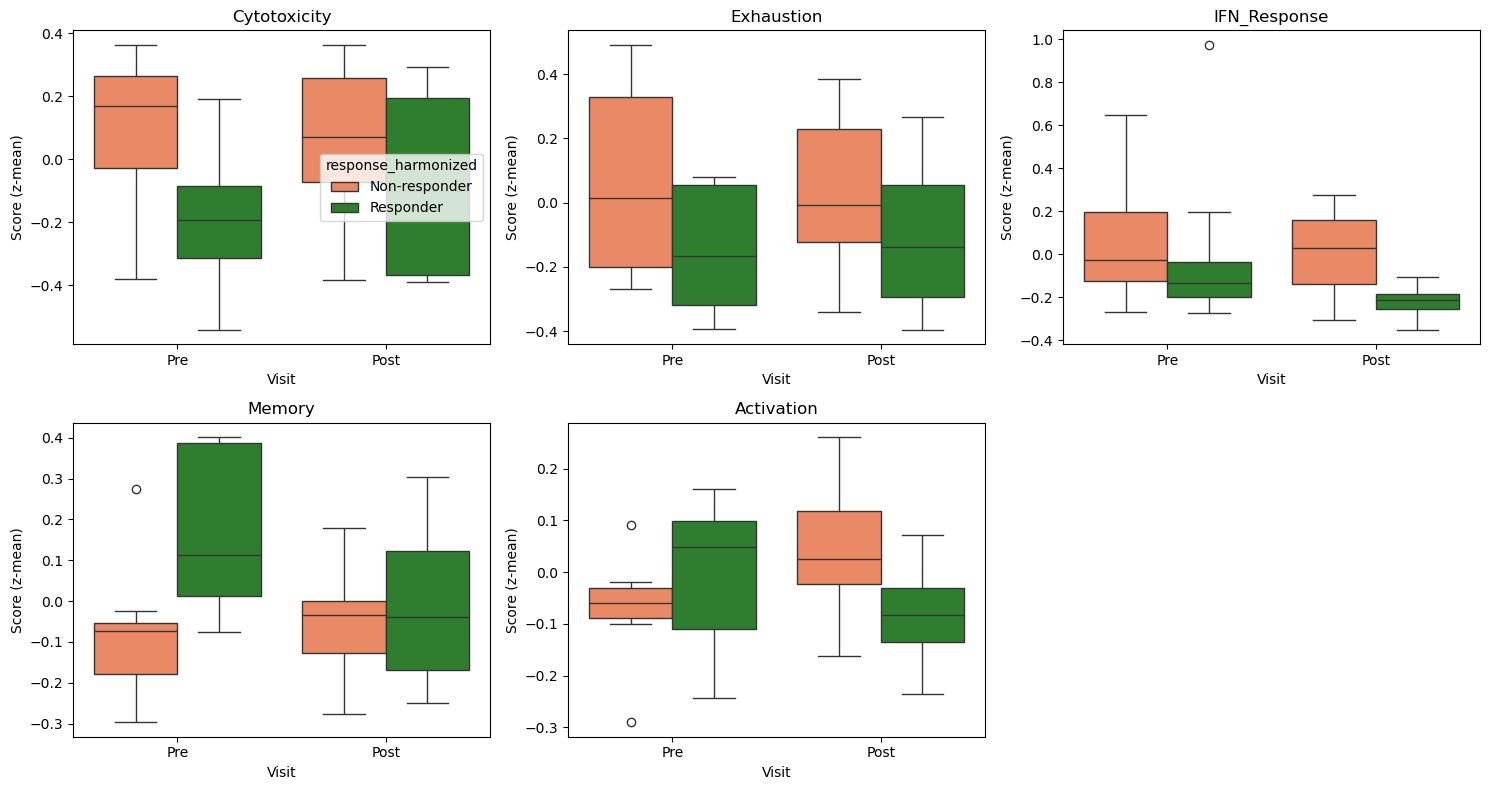

In [13]:
# Visualize signature distributions
if features_use:
    n_features = len(features_use)
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_features == 1:
        axes = np.array([[axes]])
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for i, feat in enumerate(features_use):
        ax = axes[i]
        
        # Aggregate to participant level for visualization
        df_plot = (
            adata.obs
            .groupby(["participant_id", RESPONSE_COL, "visit"], observed=True)[feat]
            .mean()
            .reset_index()
        )
        
        sns.boxplot(
            data=df_plot, x="visit", y=feat, hue=RESPONSE_COL,
            palette={"Responder": "forestgreen", "Non-responder": "coral"},
            ax=ax, order=["Pre", "Post"]
        )
        ax.set_title(feat.replace("sig_", ""))
        ax.set_xlabel("Visit")
        ax.set_ylabel("Score (z-mean)")
        if i > 0:
            ax.get_legend().remove()
    
    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("No features to visualize.")


### 8.2 Trial Interaction Plot

Shows mean trajectories for each response group from Pre to Post.

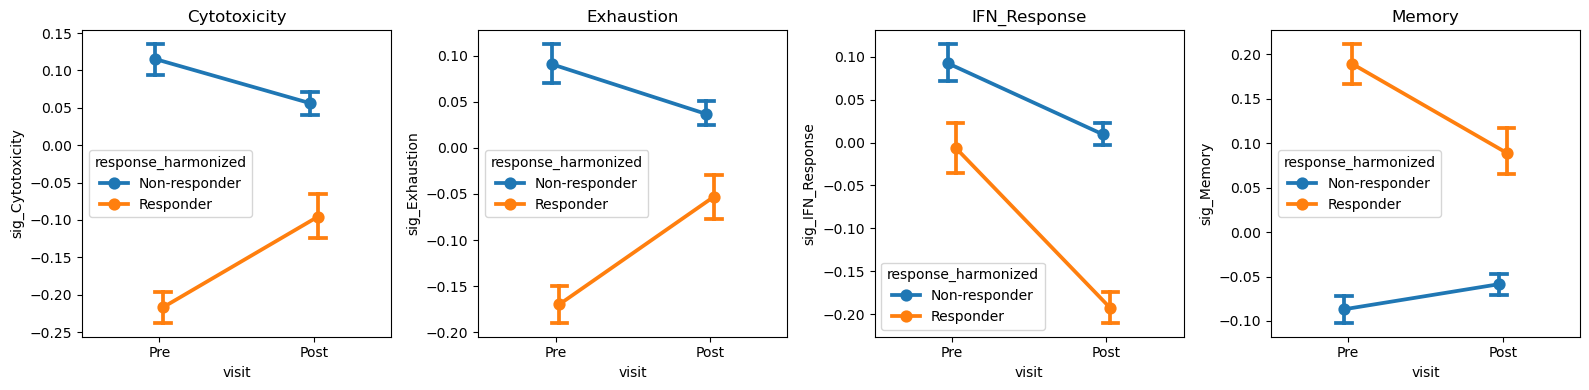

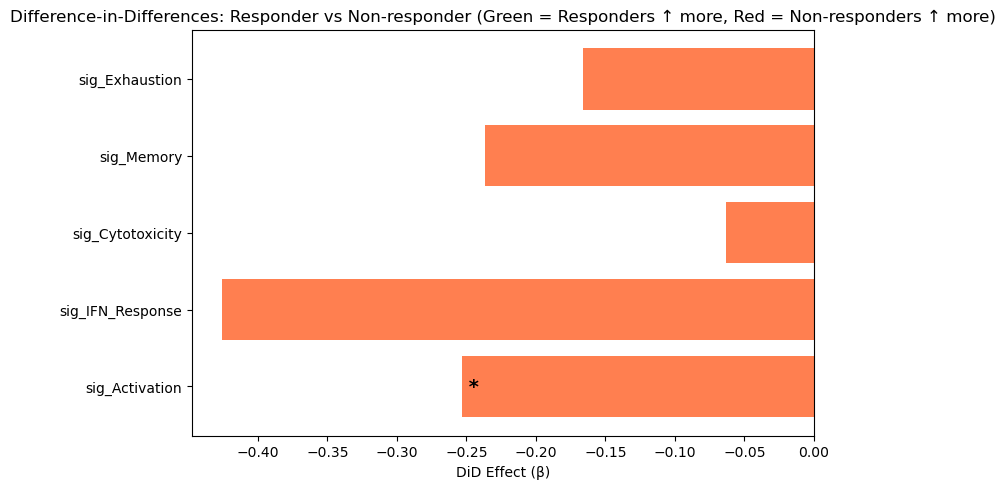

In [14]:
# Interaction plots for top features
if features_use and len(visits) == 2:
    n_plots = min(len(features_use), 4)
    fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    
    for i, feat in enumerate(features_use[:n_plots]):
        ax = axes[i]
        try:
            st.plot_trial_interaction(
                adata, feat, design=design, visits=tuple(visits), ax=ax
            )
            ax.set_title(feat.replace("sig_", ""))
        except Exception as e:
            ax.text(0.5, 0.5, f"Could not plot: {feat}", 
                   ha="center", va="center", transform=ax.transAxes)
            ax.set_title(feat.replace("sig_", ""))
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping interaction plots: insufficient visits or features.")

# DiD Bar Plot (since we don't have SE for forest plot)
if did_results is not None and not did_results.empty:
    valid_did = did_results[did_results["beta_DiD"].notna()]
    if not valid_did.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        
        colors = ["forestgreen" if b > 0 else "coral" for b in valid_did["beta_DiD"]]
        bars = ax.barh(valid_did["feature"], valid_did["beta_DiD"], color=colors)
        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_xlabel("DiD Effect (β)")
        ax.set_title("Difference-in-Differences: Responder vs Non-responder (Green = Responders ↑ more, Red = Non-responders ↑ more)")
        
        # Add significance markers
        for i, (_, row) in enumerate(valid_did.iterrows()):
            if pd.notna(row["FDR_DiD"]) and row["FDR_DiD"] < FDR_ALPHA:
                ax.text(row["beta_DiD"], i, " *", va="center", fontsize=14, fontweight="bold")
        
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping DiD plot: no valid results.")
else:
    print("Skipping DiD plot: no DiD results available.")


## 10. Advanced Statistical Analyses

In this section, we demonstrate the new statistical modules added to sctrial:
- **Effect sizes**: Cohen's d and Hedge's g with confidence intervals
- **Power analysis**: Sample size planning and power curves
- **Mixed effects models**: Comparison with fixed effects DiD
- **Cross-validation**: Leave-one-out CV for effect stability
- **Effective sample size**: Accounting for clustering

### 10.1 Effect Sizes with Confidence Intervals

Effect sizes (Cohen's d, Hedge's g) provide standardized measures of treatment effects that are independent of sample size and complement p-values.

In [15]:
print("=" * 60)
print("EFFECT SIZE ANALYSIS")
print("=" * 60)

# Calculate effect sizes for the DiD results
if features_use and did_results is not None and not did_results.empty:
    # Aggregate to participant-visit level for effect size calculation
    df_agg = (
        adata.obs[adata.obs[design.participant_col].isin(VALID_PAIRED_ALL)]
        .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
        .mean()
        .reset_index()
    )

    effect_size_results = []
    for feat in features_use:
        # Calculate deltas for each participant
        wide = df_agg.pivot_table(
            index=design.participant_col,
            columns=design.visit_col,
            values=feat,
            aggfunc="mean"
        )
        if visits[0] not in wide.columns or visits[1] not in wide.columns:
            continue

        wide["delta"] = wide[visits[1]] - wide[visits[0]]
        wide = wide.dropna(subset=["delta"])
        wide["arm"] = wide.index.map(participant_response)

        delta_resp = wide[wide["arm"] == design.arm_treated]["delta"].values
        delta_nonresp = wide[wide["arm"] == design.arm_control]["delta"].values

        if len(delta_resp) >= 2 and len(delta_nonresp) >= 2:
            # Cohen's d
            d = st.cohens_d(delta_resp, delta_nonresp)
            # Hedge's g (bias-corrected, recommended for small samples)
            g = st.hedges_g(delta_resp, delta_nonresp)
            # Bootstrap confidence interval (correct signature)
            # Note: CI may be NaN if sample size is too small or variance is zero
            try:
                g_est, ci_low, ci_high = st.bootstrap_effect_size_ci(
                    delta_resp, delta_nonresp,
                    method="hedges_g",
                    n_boot=999,
                    alpha=0.05,
                    seed=SEED,
                )
            except Exception:
                ci_low, ci_high = float('nan'), float('nan')

            effect_size_results.append({
                "feature": feat,
                "cohens_d": d,
                "hedges_g": g,
                "ci_lower": ci_low,
                "ci_upper": ci_high,
                "n_resp": len(delta_resp),
                "n_nonresp": len(delta_nonresp),
            })

    if effect_size_results:
        df_effect = pd.DataFrame(effect_size_results)

        print("")
        print("Effect sizes for DiD (Responder vs Non-responder change):")
        print("  Cohen's d: standardized effect size")
        print("  Hedge's g: bias-corrected (recommended for small samples)")
        print("  95% CI: bootstrap confidence interval (may be NaN if n is too small)")
        display(df_effect.round(3))
else:
    print("No valid features for effect size analysis.")


EFFECT SIZE ANALYSIS

Effect sizes for DiD (Responder vs Non-responder change):
  Cohen's d: standardized effect size
  Hedge's g: bias-corrected (recommended for small samples)
  95% CI: bootstrap confidence interval (may be NaN if n is too small)


,feature,cohens_d,hedges_g,ci_lower,ci_upper,n_resp,n_nonresp
0,sig_Cytotoxicity,-0.195,-0.176,-1.947,1.632,3,7
1,sig_Exhaustion,-0.694,-0.627,-2.410,0.795,3,7
2,sig_IFN_Response,-1.160,-1.047,-6.691,0.401,3,7
3,sig_Memory,-0.730,-0.659,-5.607,1.441,3,7
4,sig_Activation,-2.840,-2.565,-5.461,-1.823,3,7


### 10.2 Power Analysis

Power analysis helps understand the statistical power of the current study and plan future studies.

POWER ANALYSIS

Current sample (paired participants):
  Responders: 3
  Non-responders: 7
  Average per arm: 5.0

Power with current sample size (n=5 per arm):
  Effect size d=0.5: 12.4% power
  Effect size d=0.8: 24.4% power
  Effect size d=1.0: 35.3% power
  Effect size d=1.5: 66.0% power

Sample size needed for 80% power:
  Effect size d=0.5: 63 per arm (126 total)
  Effect size d=0.8: 25 per arm (50 total)
  Effect size d=1.0: 16 per arm (32 total)
  Effect size d=1.5: 7 per arm (14 total)


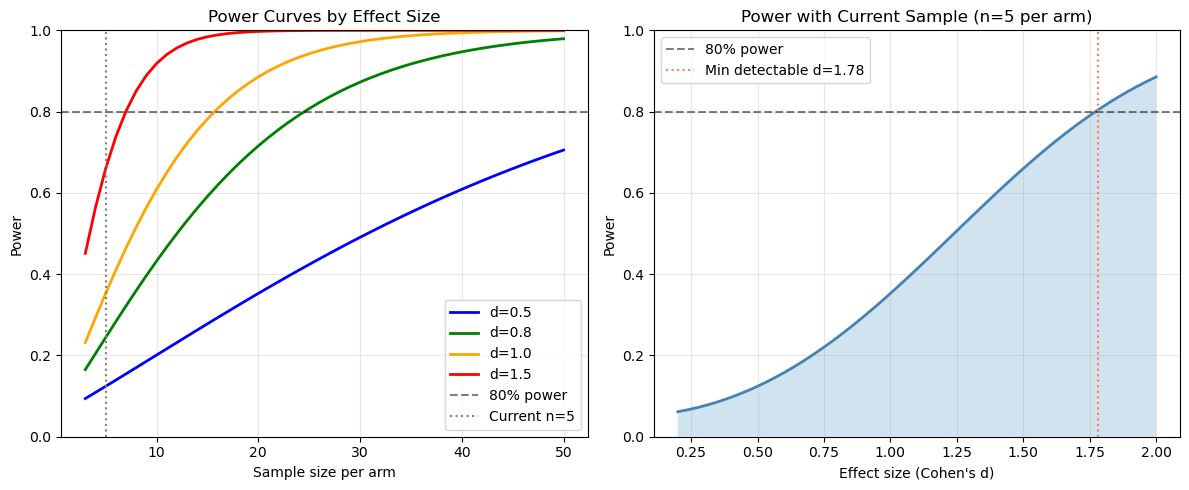


EFFECTIVE SAMPLE SIZE

Average cells per participant: 527

Design effect and effective sample size (total cells vs effective n):
  ICC = intraclass correlation (cells within participant)
  ICC=0.01: Design effect=6.3, Effective n=1109921 (vs 13,183 cells)
  ICC=0.05: Design effect=27.3, Effective n=254490 (vs 13,183 cells)
  ICC=0.1: Design effect=53.6, Effective n=129618 (vs 13,183 cells)
  ICC=0.2: Design effect=106.3, Effective n=65419 (vs 13,183 cells)

Note: DiD correctly aggregates to participant level, so design effect
is already accounted for. Cell counts help reduce within-participant noise.


In [16]:
print("=" * 60)
print("POWER ANALYSIS")
print("=" * 60)

# Current sample sizes
n_resp_paired = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_treated, set()))
n_nonresp_paired = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_control, set()))
n_avg = (n_resp_paired + n_nonresp_paired) / 2

print(f"\nCurrent sample (paired participants):")
print(f"  Responders: {n_resp_paired}")
print(f"  Non-responders: {n_nonresp_paired}")
print(f"  Average per arm: {n_avg:.1f}")

# Power for different effect sizes with current sample
print(f"\nPower with current sample size (n={n_avg:.0f} per arm):")
for effect_size in [0.5, 0.8, 1.0, 1.5]:
    power = st.power_did(n_per_group=int(n_avg), effect_size=effect_size)
    print(f"  Effect size d={effect_size}: {power:.1%} power")

# Sample size needed for 80% power
print("\nSample size needed for 80% power:")
for effect_size in [0.5, 0.8, 1.0, 1.5]:
    n_needed = st.sample_size_did(effect_size=effect_size, power=0.80)
    print(f"  Effect size d={effect_size}: {n_needed} per arm ({2*n_needed} total)")

# Power curve visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Power curve across sample sizes
n_range = np.arange(3, 51)
for effect_size, color in [(0.5, "blue"), (0.8, "green"), (1.0, "orange"), (1.5, "red")]:
    powers = [st.power_did(n_per_group=n, effect_size=effect_size) for n in n_range]
    axes[0].plot(n_range, powers, label=f"d={effect_size}", color=color, linewidth=2)

axes[0].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[0].axvline(n_avg, color="gray", linestyle=":", label=f"Current n={n_avg:.0f}")
axes[0].set_xlabel("Sample size per arm")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Curves by Effect Size")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Power curve with current sample size across effect sizes
effect_range = np.linspace(0.2, 2.0, 50)
power_current = [st.power_did(n_per_group=int(n_avg), effect_size=e) for e in effect_range]
axes[1].plot(effect_range, power_current, linewidth=2, color="steelblue")
axes[1].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[1].fill_between(effect_range, 0, power_current, alpha=0.2)
axes[1].set_xlabel("Effect size (Cohen's d)")
axes[1].set_ylabel("Power")
axes[1].set_title(f"Power with Current Sample (n={int(n_avg)} per arm)")
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Mark detectable effect size at 80% power
idx_80 = np.argmin(np.abs(np.array(power_current) - 0.8))
if idx_80 > 0:
    detectable_effect = effect_range[idx_80]
    axes[1].axvline(detectable_effect, color="coral", linestyle=":", 
                    label=f"Min detectable d={detectable_effect:.2f}")
    axes[1].legend()

plt.tight_layout()
plt.show()

# Effective sample size accounting for clustering
print("\n" + "=" * 60)
print("EFFECTIVE SAMPLE SIZE")
print("=" * 60)

# Calculate cells per participant
cells_per_participant = adata.obs.groupby("participant_id").size()
avg_cells = cells_per_participant.mean()
print(f"\nAverage cells per participant: {avg_cells:.0f}")

# Estimate design effect with different ICC values
print("\nDesign effect and effective sample size (total cells vs effective n):")
print("  ICC = intraclass correlation (cells within participant)")
total_cells = adata.n_obs
for icc in [0.01, 0.05, 0.10, 0.20]:
    de = st.design_effect(avg_cells, icc)
    eff_n = st.effective_sample_size(total_cells, avg_cells, icc)
    print(f"  ICC={icc}: Design effect={de:.1f}, Effective n={eff_n:.0f} (vs {total_cells:,} cells)")

print("\nNote: DiD correctly aggregates to participant level, so design effect")
print("is already accounted for. Cell counts help reduce within-participant noise.")

### 10.3 Mixed Effects Models

Mixed effects models provide an alternative to fixed effects DiD by modeling participant effects as random rather than fixed. This allows for:
- Partial pooling of information across participants
- Estimation of intraclass correlation (ICC)
- Better handling of unbalanced designs

In [17]:
print("=" * 60)
print("MIXED EFFECTS MODEL COMPARISON")
print("=" * 60)

# Check if statsmodels MixedLM is available
try:
    from statsmodels.regression.mixed_linear_model import MixedLM
    HAS_MIXEDLM = True
except ImportError:
    HAS_MIXEDLM = False
    print("statsmodels MixedLM not available. Skipping mixed effects analysis.")

if HAS_MIXEDLM and features_use and len(visits) == 2:
    print("\nComparing Fixed Effects DiD vs Mixed Effects DiD")
    print("  Fixed effects: Participant-specific intercepts (removes between-subject variation)")
    print("  Mixed effects: Random participant intercepts (partial pooling)")
    
    # Run mixed effects DiD using sctrial
    print("\nRunning mixed effects models...")
    
    try:
        # Use the compare_fixed_vs_mixed function
        comparison_results = st.compare_fixed_vs_mixed(
            adata,
            features=features_use[:3],  # Limit to first 3 features for speed
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            standardize=True,
        )
        
        if comparison_results is not None and not comparison_results.empty:
            print("\nFixed vs Mixed Effects Comparison:")
            display(comparison_results.round(4))
            
            # Visualize comparison
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Plot 1: Compare beta estimates
            x = np.arange(len(comparison_results))
            width = 0.35
            
            ax = axes[0]
            ax.bar(x - width/2, comparison_results["beta_DiD_fixed"], width, 
                   label="Fixed Effects", color="steelblue")
            ax.bar(x + width/2, comparison_results["beta_DiD_mixed"], width,
                   label="Mixed Effects", color="coral")
            ax.set_xticks(x)
            ax.set_xticklabels(comparison_results["feature"], rotation=45, ha="right")
            ax.set_ylabel("DiD Estimate (β)")
            ax.set_title("DiD Estimates: Fixed vs Mixed Effects")
            ax.legend()
            ax.axhline(0, color="black", linewidth=0.5)
            
            # Plot 2: ICC values
            ax = axes[1]
            if "icc" in comparison_results.columns:
                ax.barh(comparison_results["feature"], comparison_results["icc"], color="purple")
                ax.set_xlabel("Intraclass Correlation (ICC)")
                ax.set_title("Participant-Level ICC")
                ax.axvline(0.1, color="gray", linestyle="--", alpha=0.5, label="ICC=0.1")
            else:
                ax.text(0.5, 0.5, "ICC not available", ha="center", va="center", 
                       transform=ax.transAxes)
            
            plt.tight_layout()
            plt.show()
            
            print("\nInterpretation:")
            print("  - Similar estimates suggest robust results")
            print("  - ICC indicates clustering strength (high ICC = strong participant effects)")
            print("  - Mixed effects preferred when ICC is moderate-high and sample is small")
        else:
            print("Mixed effects comparison returned no results.")
            
    except Exception as e:
        print(f"Mixed effects comparison failed: {e}")
        print("This may occur with very small samples or convergence issues.")
else:
    if not HAS_MIXEDLM:
        pass  # Already printed message above
    else:
        print("Mixed effects analysis skipped: insufficient features or visits.")

MIXED EFFECTS MODEL COMPARISON

Comparing Fixed Effects DiD vs Mixed Effects DiD
  Fixed effects: Participant-specific intercepts (removes between-subject variation)
  Mixed effects: Random participant intercepts (partial pooling)

Running mixed effects models...


Mixed effects comparison failed: No module named 'sctrial._extract'
This may occur with very small samples or convergence issues.


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


### 10.4 Cross-Validation for Effect Stability

Leave-one-out cross-validation (LOO-CV) helps assess the stability of DiD estimates and identify influential participants.

In [18]:
print("=" * 60)
print("CROSS-VALIDATION: EFFECT STABILITY")
print("=" * 60)

if features_use and len(visits) == 2 and len(VALID_PAIRED_ALL) >= 5:
    print(f"\nRunning leave-one-out cross-validation on {len(VALID_PAIRED_ALL)} paired participants...")
    print("This assesses how stable DiD estimates are when each participant is removed.")
    
    # Run LOO-CV for the first feature
    test_feature = features_use[0]
    print(f"\nFeature: {test_feature}")
    
    try:
        loo_results = st.loo_cv_did(
            adata,
            features=[test_feature],
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            standardize=True,
        )
        
        if loo_results is not None and not loo_results.empty:
            # Get summary statistics
            cv_stats = st.cv_summary(loo_results)
            
            print("\nLOO-CV Results:")
            print(f"  Full sample estimate: {cv_stats['mean_estimate'].values[0]:.4f}")
            print(f"  Mean LOO estimate: {cv_stats['mean_loo'].values[0]:.4f}")
            print(f"  Std of LOO estimates: {cv_stats['std_loo'].values[0]:.4f}")
            print(f"  CV (coefficient of variation): {cv_stats['cv'].values[0]:.2%}")
            
            # Identify influential participants
            influence = st.influence_diagnostics(loo_results)
            if not influence.empty:
                print("\nInfluence Diagnostics:")
                display(influence.round(4))
                
                # Flag highly influential participants (|influence| > 2 SD)
                threshold = 2 * influence["influence"].std()
                influential = influence[influence["influence"].abs() > threshold]
                if not influential.empty:
                    print(f"\nHighly influential participants (|influence| > 2 SD):")
                    for _, row in influential.iterrows():
                        direction = "increases" if row["influence"] > 0 else "decreases"
                        print(f"  {row['excluded']}: removing {direction} estimate by {abs(row['influence']):.3f}")
            
            # Visualize LOO estimates
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Plot 1: LOO estimates distribution
            ax = axes[0]
            ax.hist(loo_results["beta_DiD"], bins=10, edgecolor="black", alpha=0.7)
            ax.axvline(cv_stats["mean_estimate"].values[0], color="red", 
                      linewidth=2, label="Full sample")
            ax.axvline(cv_stats["mean_loo"].values[0], color="blue", 
                      linestyle="--", label="Mean LOO")
            ax.set_xlabel("DiD Estimate")
            ax.set_ylabel("Frequency")
            ax.set_title(f"LOO-CV Estimates Distribution\n{test_feature}")
            ax.legend()
            
            # Plot 2: Influence plot
            ax = axes[1]
            if not influence.empty:
                colors = ["coral" if inf > 0 else "steelblue" for inf in influence["influence"]]
                ax.barh(influence["excluded"], influence["influence"], color=colors)
                ax.axvline(0, color="black", linewidth=0.5)
                ax.set_xlabel("Influence (change in estimate when removed)")
                ax.set_ylabel("Excluded Participant")
                ax.set_title("Participant Influence on DiD Estimate")
            
            plt.tight_layout()
            plt.show()
            
        else:
            print("LOO-CV returned no results.")
            
    except Exception as e:
        print(f"LOO-CV failed: {e}")
        
else:
    print("Cross-validation requires ≥5 paired participants and valid features.")

CROSS-VALIDATION: EFFECT STABILITY

Running leave-one-out cross-validation on 10 paired participants...
This assesses how stable DiD estimates are when each participant is removed.

Feature: sig_Cytotoxicity
LOO-CV failed: loo_cv_did() got an unexpected keyword argument 'aggregate'
